# Experiment 5: Bootstrap and Permutation Resampling

**Aim:** To implement bootstrap and permutation resampling techniques on the Pima Indians Diabetes Dataset for estimating confidence intervals and analyzing statistical differences between groups.

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 2. Select a Numerical Variable

In [2]:
# Glucose is selected

glucose = df["Glucose"]

print("Sample Mean:", glucose.mean())
print("Sample Size:", len(glucose))

Sample Mean: 121.67708333333333
Sample Size: 768


## 3. Generate Bootstrap Samples

In [3]:
n_bootstrap = 10000
bootstrap_means = []

for i in range(n_bootstrap):
    sample = np.random.choice(
        glucose,
        size=len(glucose),
        replace=True
    )
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

print("Number of bootstrap samples:", len(bootstrap_means))

Number of bootstrap samples: 10000


## 4. Calculate Bootstrap Statistics

In [4]:
print("Original Sample Mean:", glucose.mean())
print("Mean of Bootstrap Means:", bootstrap_means.mean())
print("Standard Error:", bootstrap_means.std())

Original Sample Mean: 121.67708333333333
Mean of Bootstrap Means: 121.674115234375
Standard Error: 1.101414656970021


## 5. Construct a 95% Bootstrap Confidence Interval

In [5]:
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval:")
print("(", lower, ",", upper, ")")

95% Bootstrap Confidence Interval:
( 119.53636067708332 , 123.859375 )


## 6. Visualize the Bootstrap Distribution

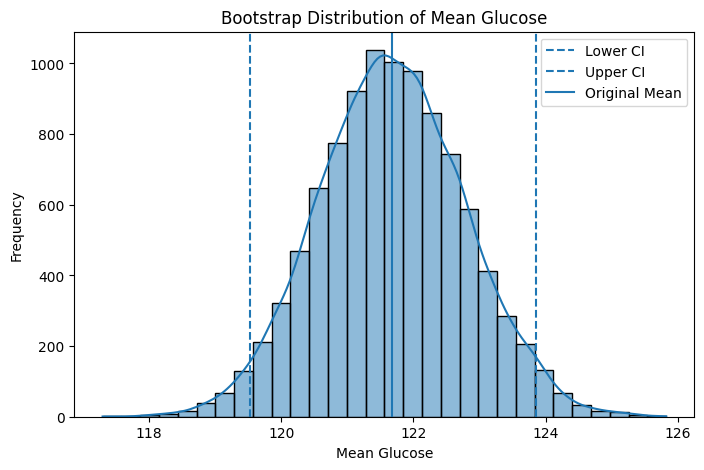

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(bootstrap_means, bins=30, kde=True)

plt.axvline(lower, linestyle="--", label="Lower CI")
plt.axvline(upper, linestyle="--", label="Upper CI")
plt.axvline(glucose.mean(), linestyle="-", label="Original Mean")

plt.title("Bootstrap Distribution of Mean Glucose")
plt.xlabel("Mean Glucose")
plt.ylabel("Frequency")
plt.legend()

plt.show()

## 7. Divide Data into Two Groups

In [7]:
diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

observed_difference = diabetic.mean() - non_diabetic.mean()

print("Mean Glucose - Diabetic:", diabetic.mean())
print("Mean Glucose - Non-diabetic:", non_diabetic.mean())
print("Observed Difference:", observed_difference)

Mean Glucose - Diabetic: 142.30223880597015
Mean Glucose - Non-diabetic: 110.622
Observed Difference: 31.68023880597015


## 8. Generate the Permutation Distribution

In [8]:
n_permutations = 10000
permutation_differences = []

combined = np.concatenate([diabetic, non_diabetic])
n_diabetic = len(diabetic)

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)

    perm_diabetic = shuffled[:n_diabetic]
    perm_non_diabetic = shuffled[n_diabetic:]

    difference = perm_diabetic.mean() - perm_non_diabetic.mean()
    permutation_differences.append(difference)

permutation_differences = np.array(permutation_differences)

## 9. Calculate Permutation p-value

In [9]:
p_value = np.mean(
    np.abs(permutation_differences) >= np.abs(observed_difference)
)

print("Observed Difference:", observed_difference)
print("Permutation p-value:", p_value)

Observed Difference: 31.68023880597015
Permutation p-value: 0.0


## 10. Visualize and Interpret the Permutation Test

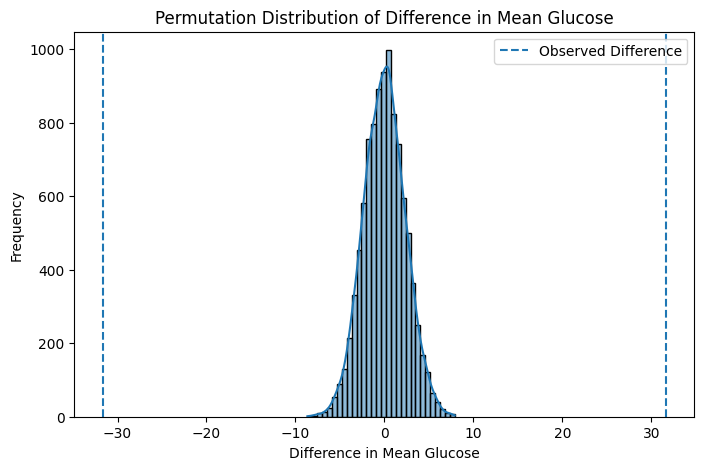

Reject H0
The difference in mean Glucose between the two groups is statistically significant.


In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(permutation_differences, bins=30, kde=True)

plt.axvline(
    observed_difference,
    linestyle="--",
    label="Observed Difference"
)

plt.axvline(
    -observed_difference,
    linestyle="--"
)

plt.title("Permutation Distribution of Difference in Mean Glucose")
plt.xlabel("Difference in Mean Glucose")
plt.ylabel("Frequency")
plt.legend()

plt.show()

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("The difference in mean Glucose between the two groups is statistically significant.")
else:
    print("Fail to reject H0")
    print("The observed difference may have occurred by chance.")

## Conclusion

Bootstrap resampling was used to estimate the sampling distribution and 95% confidence interval of the mean Glucose level. The permutation test compared the mean Glucose levels of diabetic and non-diabetic patients. The permutation p-value was used to determine whether the observed difference between the groups was statistically significant.